Sucesso! Imagem gerada e salva como 'alinhamento_tabela_colorida.png'.


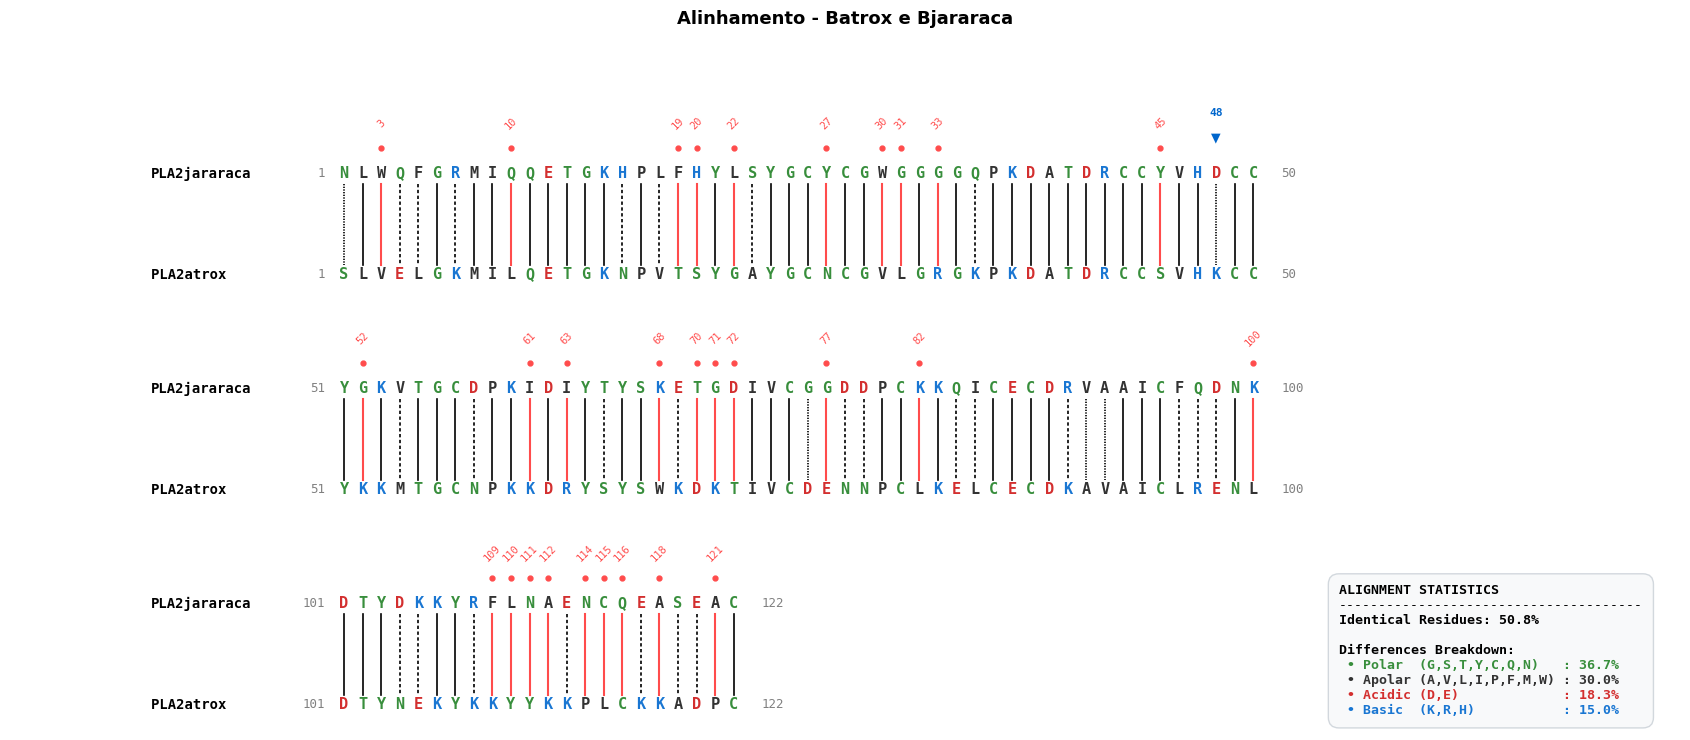

In [ ]:
# =====================================================================
# 0. CONFIGURAÇÃO PARA O GOOGLE COLAB
# =====================================================================
# Instala o Biopython caso ainda não esteja instalado
!pip install -q biopython

import os
from google.colab import files
from Bio import AlignIO
import matplotlib.pyplot as plt

# Nome do arquivo que o script espera
ARQUIVO_ALINHAMENTO = "PLA2JaraAtrox_ALINHAMENTO.aln"

# Verifica se o arquivo já existe no ambiente. Se não, pede o upload.
if not os.path.exists(ARQUIVO_ALINHAMENTO):
    print(f"⚠️ O arquivo '{ARQUIVO_ALINHAMENTO}' não foi encontrado.")
    print("Por favor, faça o upload do seu arquivo de alinhamento (.aln) abaixo:")
    uploaded = files.upload()

    # Se você fez o upload com outro nome, renomeamos para o esperado pelo script
    nome_enviado = list(uploaded.keys())[0]
    if nome_enviado != ARQUIVO_ALINHAMENTO:
        os.rename(nome_enviado, ARQUIVO_ALINHAMENTO)
        print(f"Arquivo '{nome_enviado}' renomeado para '{ARQUIVO_ALINHAMENTO}' com sucesso!")

# =====================================================================
# 1. CONFIGURAÇÕES DO USUÁRIO
# =====================================================================
TITULO_IMAGEM = "Alinhamento - Batrox e Bjararaca"

SEQUENCIA_REFERENCIA = "PLA2atrox"
RESIDUOS_ALVO = [48]  # Seus resíduos de interesse
TAMANHO_BLOCO = 50    # Resíduos por bloco

# =====================================================================
# 1.5 DEFINIÇÃO DE CORES POR PROPRIEDADE QUÍMICA
# =====================================================================
def obter_cor_aa(aa):
    aa = aa.upper()
    if aa in ['D', 'E']:
        return '#D32F2F' # Ácidos (Vermelho/Rojo)
    elif aa in ['K', 'R', 'H']:
        return '#1976D2' # Básicos (Azul)
    elif aa in ['S', 'T', 'N', 'Q', 'Y', 'C', 'G']:
        return '#388E3C' # Polares (Verde)
    elif aa in ['A', 'V', 'L', 'I', 'P', 'F', 'M', 'W']:
        return '#333333' # Apolares (Cinza Escuro/Gris oscuro)
    return 'black' # Padrão / Gaps (-)

# =====================================================================
# 2. LEITURA E MAPEAMENTO DOS RESÍDUOS
# =====================================================================
alinhamento = AlignIO.read(ARQUIVO_ALINHAMENTO, "clustal")
num_seqs = len(alinhamento)
comp_total = alinhamento.get_alignment_length()

idx_ref = next(i for i, s in enumerate(alinhamento) if s.id == SEQUENCIA_REFERENCIA)

cols_destaque = []
num_acumulada = {0: [], 1: []}

for i_seq in range(num_seqs):
    cont = 0
    for col in range(comp_total):
        if alinhamento[i_seq][col] != "-":
            cont += 1
        num_acumulada[i_seq].append(cont)
        if i_seq == idx_ref and cont in RESIDUOS_ALVO and alinhamento[i_seq][col] != "-":
            if col not in cols_destaque:
                cols_destaque.append(col)

num_blocos = (comp_total + TAMANHO_BLOCO - 1) // TAMANHO_BLOCO

if cols_destaque:
    col_min_absoluta = min(cols_destaque)
    col_max_absoluta = max(cols_destaque)
else:
    col_min_absoluta = None
    col_max_absoluta = None

# =====================================================================
# 2.5 CÁLCULO DE ESTATÍSTICAS
# =====================================================================
total_valid = 0
id_count = 0
diff_polar = 0
diff_apolar = 0
diff_acidic = 0
diff_basic = 0

for col in range(comp_total):
    aa1 = alinhamento[0][col]
    aa2 = alinhamento[1][col]

    if aa1 != "-" and aa2 != "-":
        total_valid += 1
        if aa1 == aa2:
            id_count += 1
        else:
            cor = obter_cor_aa(aa1)
            if cor == '#388E3C':   diff_polar += 1
            elif cor == '#333333': diff_apolar += 1
            elif cor == '#D32F2F': diff_acidic += 1
            elif cor == '#1976D2': diff_basic += 1

perc_id = (id_count / total_valid) * 100 if total_valid > 0 else 0
diff_total = total_valid - id_count

perc_polar = (diff_polar / diff_total) * 100 if diff_total > 0 else 0
perc_apolar = (diff_apolar / diff_total) * 100 if diff_total > 0 else 0
perc_acidic = (diff_acidic / diff_total) * 100 if diff_total > 0 else 0
perc_basic = (diff_basic / diff_total) * 100 if diff_total > 0 else 0

# =====================================================================
# 3. PLOTAGEM DO GRÁFICO
# =====================================================================
# MODIFICAÇÃO: Largura aumentada de 16 para 17 para dar folga à nova tabela
fig, ax = plt.subplots(figsize=(17, num_blocos * 2.5))

for b in range(num_blocos):
    ini = b * TAMANHO_BLOCO
    fim = min(ini + TAMANHO_BLOCO, comp_total)

    ALTURA_DO_BLOCO = 8.5
    base_y = b * ALTURA_DO_BLOCO

    y_seq1 = base_y + 3.5
    y_seq2 = base_y + 7.5

    y_barra_sup = y_seq1 + 0.4
    y_barra_inf = y_seq2 - 0.4

    dist_ponto = 1.0
    dist_num_mutacao = 2.0
    dist_seta_alvo = 1.4
    dist_num_alvo = 2.4

    if col_min_absoluta is not None and col_max_absoluta is not None:
        bar_ini_abs = max(ini, col_min_absoluta)
        bar_fim_abs = min(fim - 1, col_max_absoluta)

        if bar_ini_abs <= bar_fim_abs:
            col_idx_ini_barra = bar_ini_abs - ini
            col_idx_fim_barra = bar_fim_abs - ini
            y_barra_horizontal_azul = y_seq1 - dist_seta_alvo + 1.3

            ax.plot([col_idx_ini_barra, col_idx_fim_barra],
                    [y_barra_horizontal_azul, y_barra_horizontal_azul],
                    color='purple', linewidth=2.0, zorder=1)

    for s_idx, y_pos in enumerate([y_seq1, y_seq2]):
        ax.text(-5, y_pos, f"{alinhamento[s_idx].id:<12}", va='center', ha='right', fontsize=10, family='monospace', fontweight='bold')
        num_ini = num_acumulada[s_idx][ini] if alinhamento[s_idx][ini] != "-" else (num_acumulada[s_idx][ini] + 1 if ini+1 < comp_total else num_acumulada[s_idx][ini])
        ax.text(-1, y_pos, str(num_ini), va='center', ha='right', fontsize=9, family='monospace', color='gray')

    for col_idx, col in enumerate(range(ini, fim)):
        cons_string = alinhamento.column_annotations.get("clustal_consensus", " " * comp_total)
        cons = cons_string[col]
        aa1 = alinhamento[0][col]
        aa2 = alinhamento[1][col]

        cor_aa1 = obter_cor_aa(aa1)
        cor_aa2 = obter_cor_aa(aa2)

        ax.text(col_idx, y_seq1, aa1, va='center', ha='center', fontsize=11, family='monospace', fontweight='bold', color=cor_aa1, zorder=2)
        ax.text(col_idx, y_seq2, aa2, va='center', ha='center', fontsize=11, family='monospace', fontweight='bold', color=cor_aa2, zorder=2)

        if aa1 != "-" and aa2 != "-":
            if cons == "*":
                ax.plot([col_idx, col_idx], [y_barra_sup, y_barra_inf], color='black', linewidth=1.2)
            elif cons == ":":
                ax.plot([col_idx, col_idx], [y_barra_sup, y_barra_inf], color='black', linewidth=1.2,
                        linestyle=(0, (2, 1.5)), dash_capstyle='butt')
            elif cons == ".":
                ax.plot([col_idx, col_idx], [y_barra_sup, y_barra_inf], color='black', linewidth=1.2,
                        linestyle=(0, (0.8, 0.8)), dash_capstyle='butt')
            elif cons == " ":
                ax.plot([col_idx, col_idx], [y_barra_sup, y_barra_inf], color='#FF4C4C', linewidth=1.5)

                ax.plot(col_idx, y_seq1 - dist_ponto, marker='o', markersize=3.5, color='#FF4C4C', zorder=3)
                ax.text(col_idx, y_seq1 - dist_num_mutacao, str(num_acumulada[0][col]), va='center', ha='center', fontsize=7.5, color='#FF4C4C', family='monospace', zorder=3, rotation=45)

        if col in cols_destaque:
            num_alvo = num_acumulada[idx_ref][col]
            ax.text(col_idx, y_seq1 - dist_seta_alvo, "▼", va='center', ha='center', color='#0066CC', fontsize=9, fontweight='bold', zorder=4)
            ax.text(col_idx, y_seq1 - dist_num_alvo, str(num_alvo), va='center', ha='center', color='#0066CC', fontsize=8, family='monospace', fontweight='bold', zorder=4)

    for s_idx, y_pos in enumerate([y_seq1, y_seq2]):
        ax.text(fim - ini + 0.5, y_pos, str(num_acumulada[s_idx][fim - 1]), va='center', ha='left', fontsize=9, family='monospace', color='gray')

# =====================================================================
# 3.5 INSERÇÃO DA CAIXA DE ESTATÍSTICAS COLORIDA (NOVO)
# =====================================================================
# Coordenadas fixadas no canto inferior direito para não cruzar os alinhamentos
caixa_x = TAMANHO_BLOCO + 20
caixa_y = num_blocos * ALTURA_DO_BLOCO - 0.5

LARGURA_TEXTO = 38 # Caracteres exatos para manter o monoespaçado quadrado

linhas_tabela = [
    ("ALIGNMENT STATISTICS", "black", "bold"),
    ("-" * LARGURA_TEXTO, "black", "normal"),
    (f"Identical Residues: {perc_id:.1f}%", "black", "bold"),
    ("", "black", "normal"),
    ("Differences Breakdown:", "black", "bold"),
    (f" • Polar  (G,S,T,Y,C,Q,N)   : {perc_polar:>4.1f}%", "#388E3C", "bold"),
    (f" • Apolar (A,V,L,I,P,F,M,W) : {perc_apolar:>4.1f}%", "#333333", "bold"),
    (f" • Acidic (D,E)             : {perc_acidic:>4.1f}%", "#D32F2F", "bold"),
    (f" • Basic  (K,R,H)           : {perc_basic:>4.1f}%", "#1976D2", "bold")
]

# Truque de "Overlay": Desenhamos a caixa linha por linha para permitir cores distintas
for i, (texto, cor, peso) in enumerate(linhas_tabela):
    linhas_overlay = []
    for j in range(len(linhas_tabela)):
        if j == i:
            linhas_overlay.append(texto.ljust(LARGURA_TEXTO)) # Preenche com espaços à direita
        else:
            linhas_overlay.append(" " * LARGURA_TEXTO) # Linhas vazias invisíveis

    texto_final = "\n".join(linhas_overlay)

    if i == 0:
        # A primeira iteração desenha o fundo (bbox) da tabela
        ax.text(caixa_x, caixa_y, texto_final,
                color=cor, fontweight=peso, family='monospace', fontsize=9.5,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', edgecolor='#CED4DA', alpha=0.9),
                zorder=5)
    else:
        # As iterações seguintes sobrepõem o texto colorido perfeitamente alinhado
        ax.text(caixa_x, caixa_y, texto_final,
                color=cor, fontweight=peso, family='monospace', fontsize=9.5,
                va='bottom', ha='right', zorder=6)

# =====================================================================
# 4. CONFIGURAÇÃO DE EIXOS E SALVAMENTO
# =====================================================================
plt.title(TITULO_IMAGEM, fontsize=13, fontweight='bold', pad=35)

# Espaço horizontal expandido (+22) para caber a caixa estendida sem cortes
ax.set_xlim(-18, TAMANHO_BLOCO + 22)
ax.set_ylim((num_blocos * ALTURA_DO_BLOCO), -0.5)
ax.axis('off')

plt.tight_layout()
plt.savefig("alinhamento_tabela_colorida.png", dpi=300, bbox_inches='tight')
print("Sucesso! Imagem gerada e salva como 'alinhamento_tabela_colorida.png'.")

# Força a exibição da imagem inline no notebook do Colab
plt.show()